In [589]:
import sys
sys.path.append("../../src")
import kibble_zurek as kz
import kblock_ising_model as kb
from common_imports import *
from joblib import Parallel, delayed
from matplotlib.pyplot import imshow
import warnings
warnings.filterwarnings("ignore")
import warnings
from numpy import ComplexWarning

warnings.filterwarnings("ignore", category=ComplexWarning)


ImportError: cannot import name 'ComplexWarning' from 'numpy' (/Users/kristianmunnikhuis/miniconda3/envs/TFIM/lib/python3.11/site-packages/numpy/__init__.py)

In [489]:
def compute_P_for_g(g, U):
    print(g / gs[-1])
    return np.array([-log(kb.P_n(ni+1, U, k)/kb.P_n(ni,U,k)) for ni in ns])


# Break


In [586]:
gs = np.linspace(0,1)
L = 100
k = kb.k_vals(L)
Us = [kb.U(k,gi) for gi in gs]
ns = np.arange(2,13)
rs = np.arange(1,20)



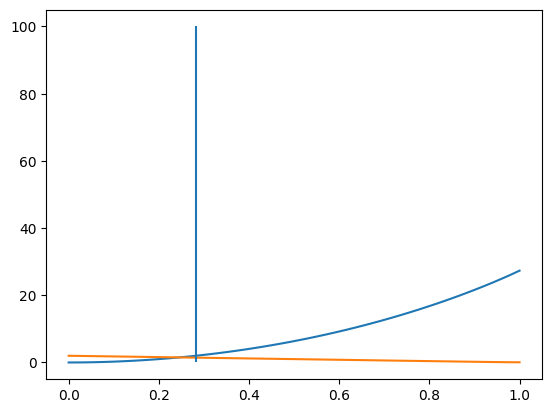

In [588]:
E0 = array([-0.5 * np.sum(kb.epsilon(k, g)) for g in gs])
E_plus = -L
DeltaE = E_plus - E0
plot(gs,DeltaE)
plot(gs,array([np.min(kb.epsilon(k,g)) for g in gs]))
plt.vlines(sqrt(8/L),0,100)
#loglog()

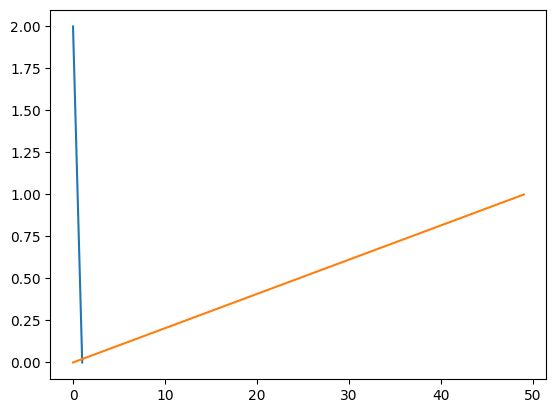

In [567]:
plot(gs,2*np.abs(1-gs))
plot(gs,)

In [568]:
P_g = Parallel(n_jobs=-1)(
    delayed(compute_P_for_g)(g, U) for g, U in zip(gs, Us)
)


0.224489795918367320.2040816326530612

0.24489795918367346
0.12244897959183673
0.0
0.08163265306122448
0.14285714285714285
0.1020408163265306
0.04081632653061224
0.16326530612244897
0.061224489795918366
0.02040816326530612
0.18367346938775508
0.26530612244897955


/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/0_correlation_length_withN/../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/0_correlation_length_withN/../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/0_correlation_length_withN/../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/0_correlation_length_withN/../../src/kblock_ising_model.py:146: ComplexWarning: Casting complex values to real discards the imaginary part
  C[nx,ny] = D(Nd,T,k)
/Users/kristianmunnikhuis/Desktop/subsystem_loschmidt_echo/scripts/0_correlation_len

0.2857142857142857
0.3061224489795918
0.32653061224489793
0.3469387755102041
0.36734693877551017
0.3877551020408163
0.4081632653061224
0.42857142857142855
0.44897959183673464
0.4693877551020408
0.4897959183673469
0.5102040816326531
0.5306122448979591
0.5510204081632653
0.5714285714285714
0.5918367346938775
0.6122448979591836
0.6326530612244897
0.6530612244897959
0.673469387755102
0.6938775510204082
0.7142857142857142
0.7346938775510203
0.7551020408163265
0.7755102040816326
0.7959183673469387
0.8163265306122448
0.836734693877551
0.8571428571428571
0.8775510204081632
0.8979591836734693
0.9183673469387754
0.9387755102040816
0.9591836734693877
0.9795918367346939
1.0


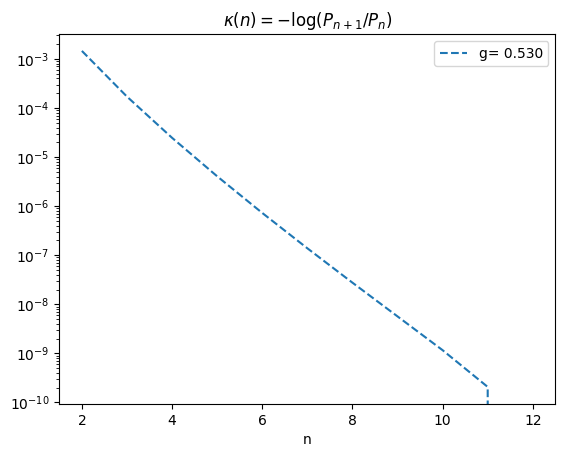

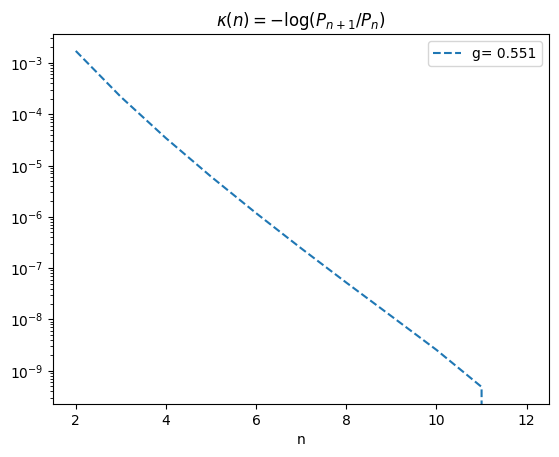

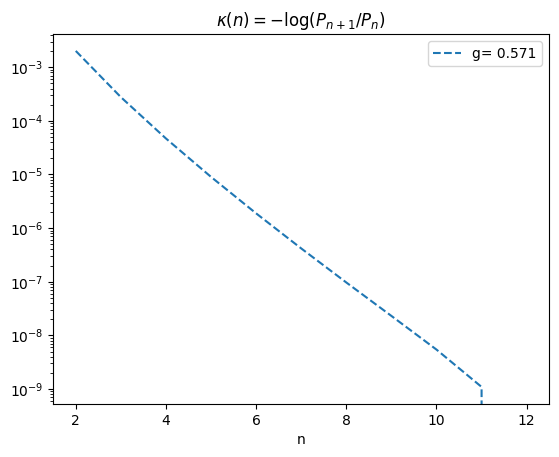

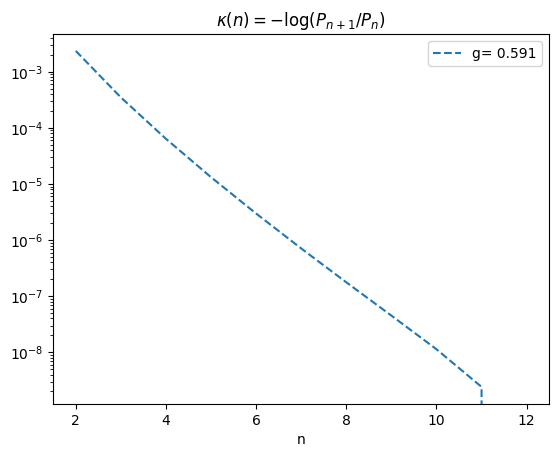

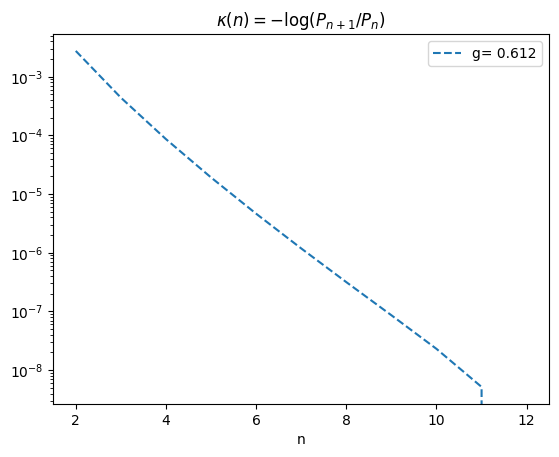

In [634]:
for p,g in zip(P_g,gs):
    if g> 2*sqrt(8/L)-.05 and g<2*sqrt(8/L)+.05:
        if g < sqrt(8/L):
            plot(ns,p-p[-1],label=f"g= {str(g)[:5]}")
        else:
            plot(ns,p-p[-1],label=f"g= {str(g)[:5]}",ls="--")
        yscale("log")
        legend()
        title(r"$\kappa(n)= - \log(P_{n+1}/P_n)$")
        xlabel("n")
        show()

#legend()
#


Text(0.5, 0, 'n')

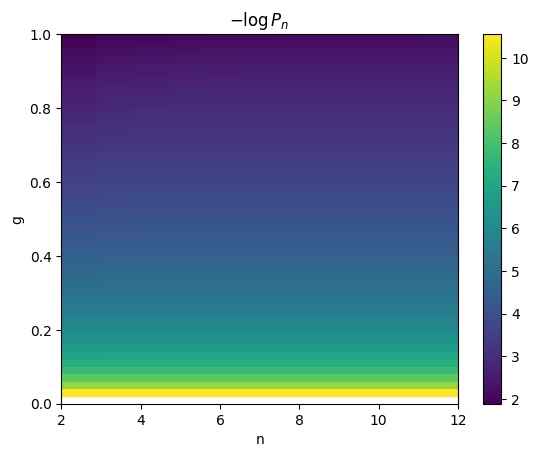

In [573]:
rates = -log(P_g)
imshow(rates,origin="lower",extent=[ns[0],ns[-1],gs[0],gs[-1]],aspect="auto")
#yscale("log")
title(r"$-\log P_n$")
plt.colorbar()
ylabel("g")
xlabel("n")

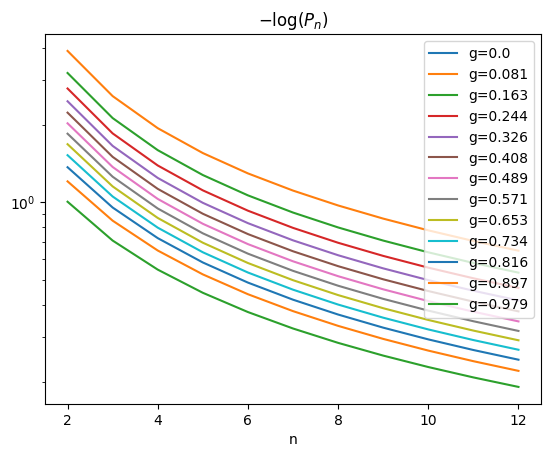

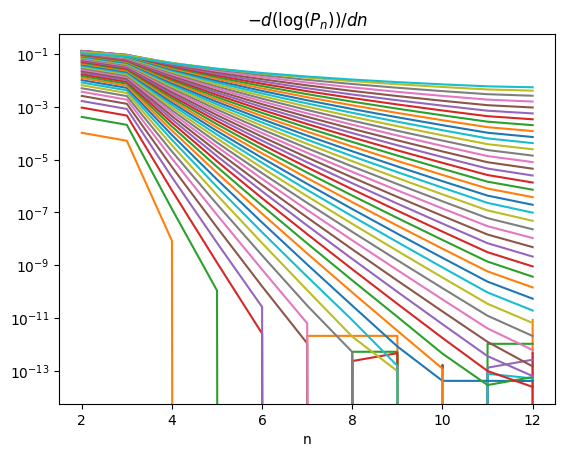

In [574]:
title(r"$-\log(P_n)$")
for g, rate in zip(gs[::4],rates[::4]):
    plot(ns,rate/ns,label=f"g={str(g)[:5]}")
    xlabel("n")
yscale("log")
legend()
show()
#plot(rates[:,0]

grates = []
title(r"$-d (\log(P_n)) /dn$")
for g, rate in zip(gs,rates):
    g_rate = np.gradient(rate,ns)
    plot(ns,g_rate,label=f"g={str(g)[:5]}")
    grates.append(g_rate)
    xlabel("n")

grates=array(grates)
#legend()
yscale("log")

show()


In [435]:
np.shape(grates)

(50, 12)

Text(0.5, 0, 'n')

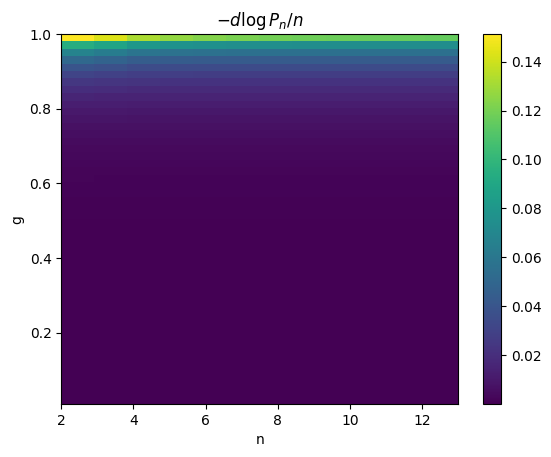

In [436]:
imshow(grates,origin="lower",extent=[ns[0],ns[-1],gs[0],gs[-1]],aspect="auto")
#yscale("log")
title(r"$-d \log P_n / n$")
plt.colorbar()
ylabel("g")
xlabel("n")

[]

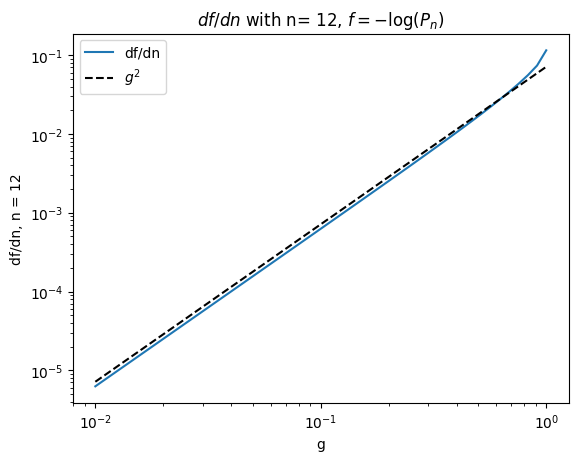

In [452]:
plot(gs,grates[:,-1],label="df/dn")
title(r"$df/dn$ with n= 12, $f = -\log(P_n)$")
xlabel("g")
ylabel("df/dn, n = 12")
plot(gs,gs**2/14,"--k",label=r"$g^2$")
legend()
loglog()

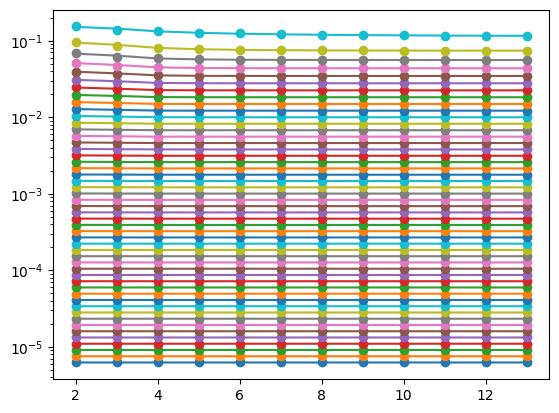

[[ 6.24972356e-06  8.46691565e-10  1.10418437e-10]
 [ 7.54205141e-06  1.23310695e-09  1.60810949e-10]
 [ 9.10159172e-06  1.79578186e-09  2.34181744e-10]
 [ 1.09835876e-05  2.61531823e-09  3.41057175e-10]
 [ 1.32546995e-05  3.80893644e-09  4.96719035e-10]
 [ 1.59953636e-05  5.54713320e-09  7.23377524e-10]
 [ 1.93026346e-05  8.07933664e-09  1.05364422e-09]
 [ 2.32936204e-05  1.17650323e-08  1.53413119e-09]
 [ 2.81096102e-05  1.71356848e-08  2.23453142e-09]
 [ 3.39210746e-05  2.49564973e-08  3.25434107e-09]
 [ 4.09336700e-05  3.63468623e-08  4.73955879e-09]
 [ 4.93954903e-05  5.29366489e-08  6.90267897e-09]
 [ 5.96058017e-05  7.70988157e-08  1.00530038e-08]
 [ 7.19255616e-05  1.12291566e-07  1.46413610e-08]
 [ 8.67900903e-05  1.63550915e-07  2.13240756e-08]
 [ 1.04724319e-04  2.38213944e-07  3.10572623e-08]
 [ 1.26361130e-04  3.46971395e-07  4.52341409e-08]
 [ 1.52463418e-04  5.05394010e-07  6.58828393e-08]
 [ 1.83950571e-04  7.36165855e-07  9.59571468e-08]
 [ 2.21930237e-04  1.07236774e-

In [474]:
def rate_fit(n,a1, b0,b1):

    return a1 + b0/n+ b1*(1+log(n))


fits = []
for g,r in zip(gs,rates):
        r = np.gradient(r,ns)
        popt, _ = curve_fit(rate_fit, ns, r)
        plot(ns,r,label =f"g= {g}")
        scatter(ns, rate_fit(ns, *popt))
        fits.append(popt)
yscale("log")
#legend()
yscale("log")
show()
fits=array(fits)
print(fits)



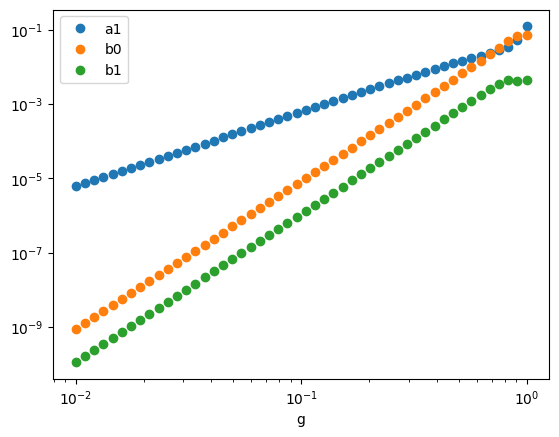

In [476]:
plot(gs,(np.abs(-fits)),"o",label=["a1","b0","b1"])
loglog()

xlabel("g")
legend()
